# 03a — Sensibilidade da completude diária dos máximos

Investiga os limiares de 95%, 90% e 80%, a distribuição das ausências e a robustez dos máximos em 2023–2024. A decisão final é exigir **260 das 288 observações diárias (90%)**, conforme [as decisões metodológicas](../DECISOES_RECORTE_TEMPORAL.md). A definição de pico (`max`, P95 ou P99) é uma questão separada.

Entrada: `data/processed/serie_temporal_filtrada_gbps.csv`. Execute a preparação abaixo e as células seguintes em ordem; nenhum estado do Notebook 03 é necessário. 2025 e janeiro de 2026 não participam dos diagnósticos.

As células históricas 23–40 do Notebook 03 foram transferidas integralmente, com seus resultados e textos originais. `MIN_OBS_DIA = 274` reproduz a referência histórica de 95%; não redefine a decisão final. Os diagnósticos adicionais ao final foram reconstruídos e executados nesta separação, pois seu código não estava salvo.

**Distinção entre os dois Welch:** o Welch horário depende da completude horária e da interpolação, não de `MIN_OBS_DIA`. O Welch dos máximos diários utiliza `picos` e é afetado pelo limiar diário. A afirmação histórica de que “o Welch usa a série horária” não se aplica ao Welch dos máximos. As comparações espectrais atuais permanecem no [Notebook 03](03_frequency_analysis.ipynb).


In [ ]:
# ------------------------------------------------------------
# importações, localização dos dados e parâmetros da análise.
# ------------------------------------------------------------


from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Funciona com o diretório de trabalho na raiz do projeto ou em notebooks/.
base_dir = next((p for p in [Path.cwd(), *Path.cwd().parents]
                 if (p / "data/processed/serie_temporal_filtrada_gbps.csv").exists()), None)
if base_dir is None:
    raise FileNotFoundError("Não foi encontrada a série processada do notebook 00.")
arquivo = base_dir / "data/processed/serie_temporal_filtrada_gbps.csv"

# Parâmetros exploratórios: não representam limites operacionais do IX.
ANO_TREINO = 2023
ANO_VALIDACAO = 2024
ANOS_ANALISE = (ANO_TREINO, ANO_VALIDACAO)
MIN_OBS_DIA = 274            # referência histórica de 95%; a decisão final é 260 (90%)
plt.rcParams.update({"figure.figsize": (12, 4), "axes.grid": True})


In [ ]:
# ------------------------------------------------------------
# Lê o recorte 2023–2024, trata inválidos e consolida timestamps duplicados.
# ------------------------------------------------------------

df = pd.read_csv(arquivo, usecols=["datahora", "total_gbps"], parse_dates=["datahora"])
if df["datahora"].isna().any():
    raise ValueError("Há timestamps inválidos; revise a preparação dos dados.")
df = df.loc[df["datahora"].dt.year.isin(ANOS_ANALISE)].copy()
if set(df["datahora"].dt.year.unique()) != set(ANOS_ANALISE):
    raise ValueError("A base precisa conter os dois anos selecionados.")
valores = pd.to_numeric(df["total_gbps"], errors="coerce")
invalidos = (~np.isfinite(valores)) | (valores < 0)
df["total_gbps"] = valores.mask(invalidos)
duplicatas = int(df["datahora"].duplicated().sum())
serie = df.groupby("datahora")["total_gbps"].mean().sort_index()
assert set(serie.index.year) == set(ANOS_ANALISE)


## Investigação histórica — células 23–40 do Notebook 03

In [27]:
# ------------------------------------------------------------
# Diagnóstico dos dias sem pico considerado válido
# ------------------------------------------------------------
# regra de picos: pelo menos 274 das 288 observações, aproximadamente 95% de cobertura diária. Os dias que tem menos observações do que o limite de cobertura que definimos não tiveram seu valor máximo como sendo representativo do pico diário. A consequencia disso é que 2024 tem 82 dias sem pico


diagnostico_picos = []

for ano in ANOS_ANALISE:

    s = serie.loc[serie.index.year == ano]

    inicio = pd.Timestamp(ano, 1, 1)
    fim = pd.Timestamp(ano + 1, 1, 1)

    grade_d = pd.date_range(
        inicio,
        fim,
        freq="D",
        inclusive="left"
    )

    dias = (
        s.resample("D")
        .agg(["max", "count"])
        .reindex(grade_d)
    )

    rejeitados = dias[dias["count"] < MIN_OBS_DIA]

    for data, linha in rejeitados.iterrows():
        diagnostico_picos.append({
            "ano": ano,
            "data": data,
            "observacoes_validas": int(linha["count"]),
            "observacoes_faltantes": 288 - int(linha["count"]),
            "cobertura_pct": 100 * linha["count"] / 288,
            "maximo_observado_gbps": linha["max"]
        })

diagnostico_picos_df = pd.DataFrame(diagnostico_picos)

display(
    diagnostico_picos_df.round({
        "cobertura_pct": 2,
        "maximo_observado_gbps": 3
    })
)

,ano,data,observacoes_validas,observacoes_faltantes,cobertura_pct,maximo_observado_gbps
0,2023,2023-04-10,241,47,83.68,4528.578
1,2023,2023-07-08,272,16,94.44,5631.139
2,2023,2023-09-30,268,20,93.06,5989.104
3,2023,2023-11-08,268,20,93.06,4626.978
4,2023,2023-11-10,236,52,81.94,4871.314
...,...,...,...,...,...,...
83,2024,2024-11-28,271,17,94.10,5567.668
84,2024,2024-12-04,269,19,93.40,6008.862
85,2024,2024-12-14,272,16,94.44,6522.470
86,2024,2024-12-17,263,25,91.32,5492.962


In [28]:
# ------------------------------------------------------------
# Resume por ano a cobertura e as observações faltantes dos dias rejeitados.
# ------------------------------------------------------------

display(
    diagnostico_picos_df
    .groupby("ano")
    .agg(
        dias_rejeitados=("data", "count"),
        obs_validas_min=("observacoes_validas", "min"),
        obs_validas_mediana=("observacoes_validas", "median"),
        obs_validas_max=("observacoes_validas", "max"),
        faltantes_mediana=("observacoes_faltantes", "median"),
        faltantes_max=("observacoes_faltantes", "max"),
        cobertura_mediana_pct=("cobertura_pct", "median")
    )
    .round(2)
)

,dias_rejeitados,obs_validas_min,obs_validas_mediana,obs_validas_max,faltantes_mediana,faltantes_max,cobertura_mediana_pct
ano,,,,,,,
2023,6,236,259.5,272,28.5,52,90.10
2024,82,194,268.0,273,20.0,94,93.06


Em 2024, os 82 dias rejeitados não são, em geral, dias “quase vazios”. A mediana é de 268 observações válidas em 288, ou seja, cerca de 93,1% de cobertura. Isso significa que muitos desses dias estão sendo descartados por pouco: faltam em torno de 20 medições, algo como 1h40 de dados ao longo do dia.
Ao mesmo tempo, existem casos mais problemáticos: o pior dia de 2024 tem 194 observações válidas, ou seja, faltam 94 medições, cerca de 7h50. Então há uma mistura de dias quase completos com alguns dias realmente mal cobertos.
Em 2023, a situação é semelhante, mas com apenas 6 dias rejeitados. A mediana de cobertura desses dias é de 90,1%, com 259,5 observações válidas.
O ponto principal é que o critério atual de MIN_OBS_DIA = 274 equivale a exigir aproximadamente 95% de cobertura diária. Esse limiar é relativamente rígido e está fazendo com que muitos dias de 2024 sejam considerados inválidos mesmo tendo mais de 90% do dia observado.
Isso explica por que o Welch dos máximos diários de 2024 tinha apenas 5/49 janelas válidas: não é porque não existam máximos nesses dias, mas porque a regra de cobertura elimina muitos deles.

In [29]:
# ------------------------------------------------------------
# 3.3.1 Sensibilidade do critério de cobertura diária
# ------------------------------------------------------------

limiares_cobertura = [0.80, 0.90, 0.95]

sensibilidade_cobertura = []

for ano in ANOS_ANALISE:
    s = serie.loc[serie.index.year == ano]

    inicio = pd.Timestamp(ano, 1, 1)
    fim = pd.Timestamp(ano + 1, 1, 1)

    grade_d = pd.date_range(
        inicio,
        fim,
        freq="D",
        inclusive="left"
    )

    dias = (
        s.resample("D")
        .agg(["max", "count"])
        .reindex(grade_d)
    )

    for limiar in limiares_cobertura:
        min_obs = int(np.ceil(288 * limiar))

        picos_teste = dias["max"].where(
            dias["count"] >= min_obs
        )

        sensibilidade_cobertura.append({
            "ano": ano,
            "cobertura_min_pct": 100 * limiar,
            "min_obs_dia": min_obs,
            "dias_validos": int(picos_teste.notna().sum()),
            "dias_invalidos": int(picos_teste.isna().sum()),
            "cobertura_dias_validos_pct": (
                100 * picos_teste.notna().mean()
            )
        })

sensibilidade_cobertura_df = pd.DataFrame(
    sensibilidade_cobertura
)

display(
    sensibilidade_cobertura_df
    .set_index(["ano", "cobertura_min_pct"])
    .round(2)
)

min_obs_dia  dias_validos  dias_invalidos  \
ano  cobertura_min_pct                                              
2023 80.0                       231           365               0   
     90.0                       260           362               3   
     95.0                       274           359               6   
2024 80.0                       231           353              13   
     90.0                       260           347              19   
     95.0                       274           284              82   

                        cobertura_dias_validos_pct  
ano  cobertura_min_pct                              
2023 80.0                                   100.00  
     90.0                                    99.18  
     95.0                                    98.36  
2024 80.0                                    96.45  
     90.0                                    94.81  
     95.0                                    77.60

In [31]:
# ------------------------------------------------------------
# 3.3.2 Diagnóstico dos dias afetados pelos limiares 95% e 90%
# ------------------------------------------------------------

ano = 2024

s = serie.loc[serie.index.year == ano]

inicio = pd.Timestamp(ano, 1, 1)
fim = pd.Timestamp(ano + 1, 1, 1)

grade_d = pd.date_range(
    inicio,
    fim,
    freq="D",
    inclusive="left"
)

dias = (
    s.resample("D")
    .agg(["max", "count"])
    .reindex(grade_d)
)

min_95 = int(np.ceil(288 * 0.95))  # 274
min_90 = int(np.ceil(288 * 0.90))  # 260

dias["valido_95"] = dias["count"] >= min_95
dias["valido_90"] = dias["count"] >= min_90

dias["grupo"] = np.select(
    [
        (~dias["valido_95"]) & (dias["valido_90"]),
        ~dias["valido_90"]
    ],
    [
        "recuperado_90",
        "invalido_90"
    ],
    default="valido_95"
)

dias["faltantes"] = 288 - dias["count"]
dias["cobertura_pct"] = 100 * dias["count"] / 288

display(
    dias.loc[
        dias["grupo"] != "valido_95",
        ["count", "faltantes", "cobertura_pct", "max", "grupo"]
    ].round(2)
)

print(dias["grupo"].value_counts())

,count,faltantes,cobertura_pct,max,grupo
2024-02-12,223,65,77.43,9591.11,invalido_90
2024-02-13,209,79,72.57,10105.37,invalido_90
2024-02-14,194,94,67.36,8130.84,invalido_90
2024-02-15,200,88,69.44,6935.84,invalido_90
2024-02-16,196,92,68.06,7430.35,invalido_90
...,...,...,...,...,...
2024-11-28,271,17,94.10,5567.67,recuperado_90
2024-12-04,269,19,93.40,6008.86,recuperado_90
2024-12-14,272,16,94.44,6522.47,recuperado_90
2024-12-17,263,25,91.32,5492.96,recuperado_90


grupo
valido_95        284
recuperado_90     63
invalido_90       19
Name: count, dtype: int64


In [33]:
# ------------------------------------------------------------
# Padrão das ausências nos dias rejeitados por 95%
# ------------------------------------------------------------

detalhes_faltas = []

datas_analisar = dias.index[dias["grupo"] != "valido_95"]

for data in datas_analisar:

    inicio_dia = data
    fim_dia = data + pd.Timedelta(days=1)

    s_dia = s.loc[
        (s.index >= inicio_dia) &
        (s.index < fim_dia)
    ]

    # Identifica intervalos entre observações consecutivas.
    # Como a frequência esperada é de aproximadamente 5 min,
    # cada intervalo maior que isso representa medições ausentes.
    idx_validos = s_dia.dropna().index.sort_values()

    blocos_faltantes = []

    if len(idx_validos) > 1:
        diferencas = idx_validos.to_series().diff()

        for timestamp, delta in diferencas.items():

            if delta > pd.Timedelta(minutes=5):

                n_faltantes = max(
                    int(round(delta / pd.Timedelta(minutes=5))) - 1,
                    0
                )

                if n_faltantes > 0:
                    blocos_faltantes.append({
                        "inicio": timestamp - delta + pd.Timedelta(minutes=5),
                        "fim": timestamp - pd.Timedelta(minutes=5),
                        "n_faltantes": n_faltantes,
                        "duracao_min": n_faltantes * 5
                    })

    if blocos_faltantes:
        maior = max(
            blocos_faltantes,
            key=lambda x: x["duracao_min"]
        )

        maior_bloco_min = maior["duracao_min"]
        maior_bloco_inicio = maior["inicio"]
        maior_bloco_fim = maior["fim"]
        n_blocos = len(blocos_faltantes)

    else:
        maior_bloco_min = 0
        maior_bloco_inicio = pd.NaT
        maior_bloco_fim = pd.NaT
        n_blocos = 0

    detalhes_faltas.append({
        "data": data.date(),
        "grupo": dias.loc[data, "grupo"],
        "observacoes_validas": int(dias.loc[data, "count"]),
        "faltantes": int(dias.loc[data, "faltantes"]),
        "cobertura_pct": dias.loc[data, "cobertura_pct"],
        "n_blocos_ausentes": n_blocos,
        "maior_bloco_min": maior_bloco_min,
        "maior_bloco_inicio": maior_bloco_inicio,
        "maior_bloco_fim": maior_bloco_fim
    })

detalhes_faltas_df = pd.DataFrame(detalhes_faltas)

display(
    detalhes_faltas_df
    .sort_values(
        ["grupo", "maior_bloco_min"],
        ascending=[True, False]
    )
    .round(2)
)

<positron-console-cell-33>:83: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,data,grupo,observacoes_validas,faltantes,cobertura_pct,n_blocos_ausentes,maior_bloco_min,maior_bloco_inicio,maior_bloco_fim
0,2024-02-12,invalido_90,223,65,77.43,36,40,2024-02-12 17:37:29,2024-02-12 18:12:29
3,2024-02-15,invalido_90,200,88,69.44,43,40,2024-02-15 04:22:29,2024-02-15 04:57:29
19,2024-03-16,invalido_90,230,58,79.86,34,40,2024-03-16 22:57:29,2024-03-16 23:32:29
13,2024-03-10,invalido_90,219,69,76.04,38,35,2024-03-10 23:22:29,2024-03-10 23:52:29
15,2024-03-12,invalido_90,220,68,76.39,37,35,2024-03-12 05:22:29,2024-03-12 05:52:29
...,...,...,...,...,...,...,...,...,...
73,2024-11-22,recuperado_90,267,21,92.71,14,10,2024-11-22 08:27:29,2024-11-22 08:32:29
74,2024-11-23,recuperado_90,273,15,94.79,13,10,2024-11-23 12:02:29,2024-11-23 12:07:29
79,2024-12-14,recuperado_90,272,16,94.44,14,10,2024-12-14 09:22:29,2024-12-14 09:27:29
81,2024-12-20,recuperado_90,272,16,94.44,14,10,2024-12-20 19:52:29,2024-12-20 19:57:29


In [34]:
# ------------------------------------------------------------
# Resumo dos padrões de ausência
# ------------------------------------------------------------

resumo_blocos = (
    detalhes_faltas_df
    .groupby("grupo")
    .agg(
        n_dias=("data", "count"),
        faltantes_mediana=("faltantes", "median"),
        faltantes_max=("faltantes", "max"),
        maior_bloco_mediana_min=("maior_bloco_min", "median"),
        maior_bloco_max_min=("maior_bloco_min", "max")
    )
)

display(resumo_blocos.round(2))

,n_dias,faltantes_mediana,faltantes_max,maior_bloco_mediana_min,maior_bloco_max_min
grupo,,,,,
invalido_90,19,65.0,94,25.0,40
recuperado_90,63,18.0,27,15.0,25


In [35]:
# ------------------------------------------------------------
# 3.3.3 Horário dos máximos diários: dias válidos a 95% e dias recuperados a 90%
# ------------------------------------------------------------

horarios_maximos = []

for data in dias.index:
    grupo = dias.loc[data, "grupo"]

    if grupo not in ["valido_95", "recuperado_90"]:
        continue

    inicio_dia = data
    fim_dia = data + pd.Timedelta(days=1)

    s_dia = s.loc[
        (s.index >= inicio_dia) &
        (s.index < fim_dia)
    ].dropna()

    if s_dia.empty:
        continue

    idx_max = s_dia.idxmax()

    horarios_maximos.append({
        "data": data.date(),
        "grupo": grupo,
        "maximo_gbps": s_dia.max(),
        "hora_maximo": idx_max.hour + idx_max.minute / 60
    })

horarios_maximos_df = pd.DataFrame(horarios_maximos)

display(
    horarios_maximos_df
    .groupby("grupo")
    .agg(
        n_dias=("data", "count"),
        hora_mediana=("hora_maximo", "median"),
        hora_media=("hora_maximo", "mean"),
        maximo_mediano_gbps=("maximo_gbps", "median")
    )
    .round(2)
)

,n_dias,hora_mediana,hora_media,maximo_mediano_gbps
grupo,,,,
recuperado_90,63,18.87,16.18,5710.49
valido_95,284,15.32,13.79,5643.25


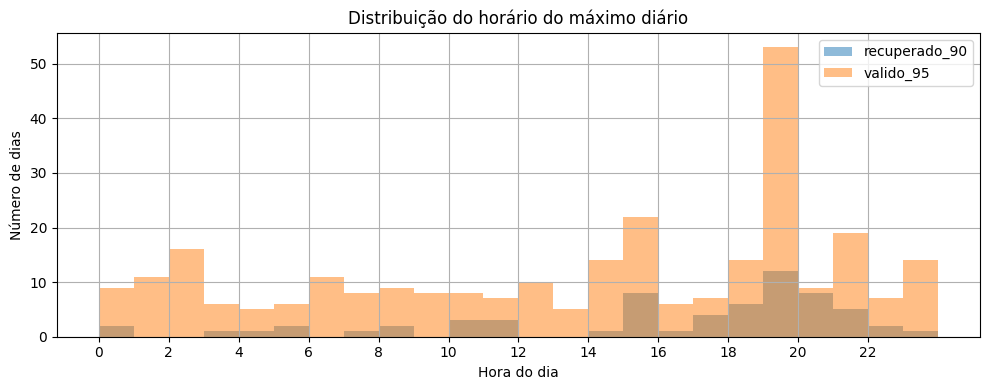

In [36]:
# ------------------------------------------------------------
# Distribuição do horário do máximo
# ------------------------------------------------------------

fig, ax = plt.subplots(figsize=(10, 4))

for grupo, df_grupo in horarios_maximos_df.groupby("grupo"):
    ax.hist(
        df_grupo["hora_maximo"],
        bins=np.arange(0, 25, 1),
        alpha=0.5,
        label=grupo
    )

ax.set(
    xlabel="Hora do dia",
    ylabel="Número de dias",
    title="Distribuição do horário do máximo diário"
)

ax.set_xticks(range(0, 24, 2))
ax.legend()

plt.tight_layout()
plt.show()

In [40]:
# ------------------------------------------------------------
# 3.3.3 Distribuição das ausências dentro dos dias
# ------------------------------------------------------------

detalhes_faltas = []

for data, row in dias.iterrows():

    # Valores pertencentes ao dia
    s_dia = s.loc[
        (s.index >= data) &
        (s.index < data + pd.Timedelta(days=1))
    ]

    # A grade temporal já está completa em passos de 5 minutos.
    # Portanto, basta identificar quais posições possuem NaN.
    faltando = s_dia.isna().to_numpy()

    # Comprimentos dos blocos consecutivos de valores ausentes
    blocos = []
    bloco_atual = 0

    for ausente in faltando:
        if ausente:
            bloco_atual += 1
        elif bloco_atual > 0:
            blocos.append(bloco_atual)
            bloco_atual = 0

    # Caso o dia termine dentro de uma lacuna
    if bloco_atual > 0:
        blocos.append(bloco_atual)

    maior_bloco = max(blocos) if blocos else 0

    detalhes_faltas.append({
        "data": data,
        "grupo": row["grupo"],
        "count": row["count"],
        "faltantes": row["faltantes"],
        "cobertura_pct": row["cobertura_pct"],
        "n_blocos": len(blocos),
        "maior_bloco_n": maior_bloco,
        "maior_bloco_min": maior_bloco * 5
    })

detalhes_faltas_df = pd.DataFrame(detalhes_faltas)

display(detalhes_faltas_df.head())

,data,grupo,count,faltantes,cobertura_pct,n_blocos,maior_bloco_n,maior_bloco_min
0,2024-01-01,valido_95,288,0,100.000000,0,0,0
1,2024-01-02,valido_95,287,1,99.652778,1,1,5
2,2024-01-03,valido_95,288,0,100.000000,0,0,0
3,2024-01-04,valido_95,286,2,99.305556,2,1,5
4,2024-01-05,valido_95,287,1,99.652778,1,1,5


In [41]:
# ------------------------------------------------------------
# 3.3.4 Resumo dos padrões de ausência por grupo
# ------------------------------------------------------------

resumo_blocos = (
    detalhes_faltas_df
    .groupby("grupo")
    .agg(
        n_dias=("data", "count"),
        faltantes_mediana=("faltantes", "median"),
        faltantes_max=("faltantes", "max"),
        n_blocos_mediana=("n_blocos", "median"),
        maior_bloco_mediana_min=("maior_bloco_min", "median"),
        maior_bloco_max_min=("maior_bloco_min", "max")
    )
)

display(resumo_blocos.round(2))

,n_dias,faltantes_mediana,faltantes_max,n_blocos_mediana,maior_bloco_mediana_min,maior_bloco_max_min
grupo,,,,,,
invalido_90,19,65.0,94,38.0,25.0,40
recuperado_90,63,18.0,27,13.0,15.0,25
valido_95,284,6.0,14,4.5,10.0,30


**Revisão do critério de completude diária. O limiar inicialmente adotado de 95% das 288 observações esperadas por dia mostrou-se restritivo em 2024. A redução para 90% recupera 63 dias que seriam descartados pelo critério anterior. Nesses dias, a mediana é de 18 observações ausentes, distribuídas em 13 blocos, e o maior bloco contínuo apresenta mediana de 15 minutos e máximo de 25 minutos. Para comparação, entre os dias já considerados válidos pelo limiar de 95%, o maior bloco contínuo chega a 30 minutos. Assim, os dias adicionais recuperados pelo limiar de 90% não apresentam longas interrupções contínuas, mas predominantemente pequenas lacunas distribuídas ao longo do dia**

In [48]:
# ------------------------------------------------------------
# 3.3.5 Proximidade das ausências em relação ao máximo diário
# ------------------------------------------------------------

diagnostico_picos = []

for data, row in dias.loc[
    dias["grupo"] == "recuperado_90"
].iterrows():

    s_dia = s.loc[
        (s.index >= data) &
        (s.index < data + pd.Timedelta(days=1))
    ]

    # Horário do máximo observado
    if s_dia.notna().any():
        instante_max = s_dia.idxmax()
    else:
        instante_max = pd.NaT

    # Instantes ausentes
    instantes_ausentes = s_dia.index[s_dia.isna()]

    if len(instantes_ausentes) > 0 and pd.notna(instante_max):
        distancias_min = np.abs(
            (instantes_ausentes - instante_max)
            .total_seconds()
            / 60
        )

        distancia_minima = distancias_min.min()
    else:
        distancia_minima = np.nan

    diagnostico_picos.append({
        "data": data,
        "maximo": row["max"],
        "instante_maximo": instante_max,
        "hora_maximo": (
            instante_max.hour +
            instante_max.minute / 60
            if pd.notna(instante_max)
            else np.nan
        ),
        "faltantes": row["faltantes"],
        "distancia_min_ausencia_ao_maximo":
            distancia_minima
    })

diagnostico_picos_df = pd.DataFrame(diagnostico_picos)

display(
    diagnostico_picos_df.sort_values(
        "distancia_min_ausencia_ao_maximo"
    )
)


,data,maximo,instante_maximo,hora_maximo,faltantes,distancia_min_ausencia_ao_maximo
47,2024-09-30,5585.302006,2024-09-30 19:57:29,19.950000,17,5.0
33,2024-08-29,6947.474356,2024-08-29 04:37:29,4.616667,15,5.0
37,2024-09-07,12750.775608,2024-09-07 21:07:29,21.116667,18,5.0
39,2024-09-19,5847.546612,2024-09-19 19:27:29,19.450000,17,5.0
27,2024-07-22,6695.699349,2024-07-22 20:02:29,20.033333,21,5.0
...,...,...,...,...,...,...
10,2024-05-31,5748.380822,2024-05-31 11:07:29,11.116667,15,180.0
28,2024-07-24,5993.661938,2024-07-24 17:02:29,17.033333,17,195.0
5,2024-04-26,5502.591770,2024-04-26 10:02:29,10.033333,15,205.0
7,2024-05-07,8003.819515,2024-05-07 23:22:29,23.366667,20,260.0


In [46]:
# ------------------------------------------------------------
# Resumo da proximidade das ausências ao máximo
# ------------------------------------------------------------

dist = diagnostico_picos_df[
    "distancia_min_ausencia_ao_maximo"
]

resumo_proximidade = pd.Series({
    "n_dias": len(diagnostico_picos_df),

    "distancia_mediana_min":
        dist.median(),

    "dias_com_ausencia_ate_15min":
        (dist <= 15).sum(),

    "dias_com_ausencia_ate_30min":
        (dist <= 30).sum(),

    "dias_com_ausencia_ate_60min":
        (dist <= 60).sum(),

    "dias_sem_ausencia_a_menos_de_60min":
        (dist > 60).sum()
})

display(resumo_proximidade)

n_dias                                63.0
distancia_mediana_min                 15.0
dias_com_ausencia_ate_15min           33.0
dias_com_ausencia_ate_30min           39.0
dias_com_ausencia_ate_60min           48.0
dias_sem_ausencia_a_menos_de_60min    15.0
dtype: float64

O que descobrimos sobre 95% → 90%
Em 2024, considerando 288 medições de 5 minutos esperadas por dia:
- 284 dias já são válidos com 95%.
- 63 dias são rejeitados por 95%, mas recuperados com 90%.
- 19 dias continuam inválidos mesmo com 90%.
Os 63 dias recuperados não apresentam grandes interrupções contínuas. Eles têm mediana de 18 observações ausentes (90 minutos no total), distribuídas em mediana de 13 blocos. O maior bloco ausente tem mediana de 15 min e máximo de 25 min. Nos dias já válidos a 95%, o maior bloco chega inclusive a 30 min.
Os máximos diários também têm magnitudes semelhantes: mediana de aproximadamente 5710 Gbps nos recuperados contra 5643 Gbps nos válidos a 95%.
O diagnóstico novo trouxe uma ressalva importante
Nos 63 dias recuperados, a distância mediana entre uma observação ausente e o máximo observado é de apenas 15 minutos. Além disso:
- 33/63 têm alguma ausência a até 15 min do máximo;
- 39/63 a até 30 min;
- 48/63 a até 60 min;
- somente 15/63 não têm ausência a menos de uma hora do máximo.
Portanto, embora as lacunas sejam pequenas, elas frequentemente estão próximas do máximo observado. Isso significa que não podemos concluir simplesmente que o máximo desses dias não foi afetado: o verdadeiro pico pode ter ocorrido justamente em uma das observações ausentes.
Uma correção conceitual importante
Também descobrimos que MIN_OBS_DIA não controla o Welch. Ele é usado somente aqui:
picos = dias["max"].where(dias["count"] >= MIN_OBS_DIA)


O Welch usa a série horária. A validade das janelas é determinada posteriormente por:
ok = trecho.notna().all()


Portanto, aquela comparação experimental de 5 janelas com 95% versus 33 com 90% não deve entrar como resultado do notebook. Ela não representa a implementação real do Welch.
Depois do almoço
Eu retomaria exatamente daqui: avaliar se a proximidade entre ausência e máximo realmente compromete o máximo diário. Só a distância de 5 ou 15 minutos pode exagerar o problema, porque o tráfego pode formar um pico relativamente largo — o valor imediatamente anterior/posterior pode ser praticamente igual ao máximo.
Vamos comparar os valores ao redor das lacunas próximas ao pico e quantificar o quanto o máximo diário poderia estar sendo subestimado. A partir disso decidimos, com evidência, entre manter 95%, adotar 90%, ou adotar 90% acompanhado de uma regra adicional específica para o pico.
Depois fechamos essa revisão e voltamos à revisão do Welch/Fourier propriamente dita.

In [49]:
# ------------------------------------------------------------
# 3.3.6 Robustez do máximo diário nos dias recuperados por 90%
# ------------------------------------------------------------

robustez_picos = []

for data, row in dias.loc[
    dias["grupo"] == "recuperado_90"
].iterrows():

    s_dia = s.loc[
        (s.index >= data) &
        (s.index < data + pd.Timedelta(days=1))
    ].dropna()

    if len(s_dia) == 0:
        continue

    instante_max = s_dia.idxmax()
    valor_max = s_dia.max()

    # Valores observados dentro de ±30 e ±60 min do máximo
    janela_30 = s_dia.loc[
        (s_dia.index >= instante_max - pd.Timedelta(minutes=30)) &
        (s_dia.index <= instante_max + pd.Timedelta(minutes=30))
    ]

    janela_60 = s_dia.loc[
        (s_dia.index >= instante_max - pd.Timedelta(minutes=60)) &
        (s_dia.index <= instante_max + pd.Timedelta(minutes=60))
    ]

    # Segundo maior valor observado no dia
    valores_ordenados = s_dia.sort_values(ascending=False)

    segundo_max = (
        valores_ordenados.iloc[1]
        if len(valores_ordenados) > 1
        else np.nan
    )

    robustez_picos.append({
        "data": data,
        "maximo": valor_max,
        "segundo_maximo": segundo_max,

        "segundo_max_pct_max":
            100 * segundo_max / valor_max,

        "mediana_30min_pct_max":
            100 * janela_30.median() / valor_max,

        "mediana_60min_pct_max":
            100 * janela_60.median() / valor_max,

        "n_obs_30min": len(janela_30),
        "n_obs_60min": len(janela_60)
    })

robustez_picos_df = pd.DataFrame(robustez_picos)

display(
    robustez_picos_df.round(2)
)



<positron-console-cell-49>:63: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,data,maximo,segundo_maximo,segundo_max_pct_max,mediana_30min_pct_max,mediana_60min_pct_max,n_obs_30min,n_obs_60min
0,2024-02-23,8639.85,5589.99,64.70,53.43,54.38,12,23
1,2024-02-27,5227.47,5220.31,99.86,98.97,98.25,12,23
2,2024-02-29,5494.30,5489.13,99.91,99.01,98.02,12,23
3,2024-03-17,5530.96,5390.92,97.47,95.11,94.59,13,24
4,2024-04-23,5066.67,5063.98,99.95,99.43,98.51,13,25
...,...,...,...,...,...,...,...,...
58,2024-11-28,5567.67,5526.97,99.27,98.87,97.61,13,23
59,2024-12-04,6008.86,5963.26,99.24,98.68,98.40,13,24
60,2024-12-14,6522.47,5057.96,77.55,57.46,57.46,12,24
61,2024-12-17,5492.96,5416.09,98.60,97.18,97.00,10,20


In [50]:
# ------------------------------------------------------------
# Resumo da robustez dos máximos
# ------------------------------------------------------------

resumo_robustez = robustez_picos_df[
    [
        "segundo_max_pct_max",
        "mediana_30min_pct_max",
        "mediana_60min_pct_max"
    ]
].agg(
    ["median", "mean", "min"]
)

display(resumo_robustez.round(2))

,segundo_max_pct_max,mediana_30min_pct_max,mediana_60min_pct_max
median,99.45,98.03,97.01
mean,93.80,84.13,83.49
min,50.08,21.25,19.21


Na maioria dos dias recuperados pelo limiar de 90%, o máximo diário não se apresenta como uma observação isolada. A mediana da razão entre o segundo maior valor e o máximo é 99,45%, enquanto as medianas dos valores observados em torno do máximo correspondem a 98,03% do máximo em ±30 minutos e 97,01% em ±60 minutos. Entretanto, os valores mínimos dessas métricas indicam a existência de alguns dias atípicos, que devem ser examinados individualmente antes da alteração definitiva do critério.

## Comparação da robustez entre os grupos

Aplicam-se as mesmas razões e as mesmas janelas de ±30 e ±60 minutos da investigação histórica a `valido_95`, `recuperado_90` e `invalido_90`, em 2024. O terceiro grupo é examinado apenas para comparação; seus dias continuam rejeitados pelo critério final.

Os limiares de 90%, 80% e 70% abaixo se referem à **razão segundo máximo/máximo**, não à cobertura diária. As frequências usam como denominador os dias do grupo com razão válida; os limites são estritos (`<`) e as contagens são cumulativas. Não são regras de exclusão.

In [ ]:
# ------------------------------------------------------------
# Calcula as mesmas medidas de robustez para os três grupos de completude.
# ------------------------------------------------------------

robustez_grupos = []

for data, row in dias.iterrows():

    s_dia = s.loc[
        (s.index >= data) &
        (s.index < data + pd.Timedelta(days=1))
    ].dropna()

    if len(s_dia) == 0:
        continue

    instante_max = s_dia.idxmax()
    valor_max = s_dia.max()

    # Valores observados dentro de ±30 e ±60 min do máximo
    janela_30 = s_dia.loc[
        (s_dia.index >= instante_max - pd.Timedelta(minutes=30)) &
        (s_dia.index <= instante_max + pd.Timedelta(minutes=30))
    ]

    janela_60 = s_dia.loc[
        (s_dia.index >= instante_max - pd.Timedelta(minutes=60)) &
        (s_dia.index <= instante_max + pd.Timedelta(minutes=60))
    ]

    # Segundo maior valor observado no dia
    valores_ordenados = s_dia.sort_values(ascending=False)

    segundo_max = (
        valores_ordenados.iloc[1]
        if len(valores_ordenados) > 1
        else np.nan
    )

    robustez_grupos.append({
        "data": data,
        "grupo": row["grupo"],
        "maximo": valor_max,
        "segundo_maximo": segundo_max,

        "segundo_max_pct_max":
            100 * segundo_max / valor_max,

        "mediana_30min_pct_max":
            100 * janela_30.median() / valor_max,

        "mediana_60min_pct_max":
            100 * janela_60.median() / valor_max,

        "n_obs_30min": len(janela_30),
        "n_obs_60min": len(janela_60)
    })

robustez_grupos_df = pd.DataFrame(robustez_grupos)

display(
    robustez_grupos_df.round(2)
)



aux-celula-24:62: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,data,grupo,maximo,segundo_maximo,segundo_max_pct_max,mediana_30min_pct_max,mediana_60min_pct_max,n_obs_30min,n_obs_60min
0,2024-01-01,valido_95,5642.97,5623.51,99.66,97.32,65.40,13,25
1,2024-01-02,valido_95,7559.86,7431.72,98.31,68.83,54.16,13,25
2,2024-01-03,valido_95,7412.76,7312.50,98.65,53.41,52.54,13,25
3,2024-01-04,valido_95,8105.01,7905.62,97.54,54.26,54.03,13,25
4,2024-01-05,valido_95,7345.22,7304.04,99.44,63.04,52.37,8,14
...,...,...,...,...,...,...,...,...,...
361,2024-12-27,valido_95,5761.89,5752.47,99.84,98.28,98.18,12,24
362,2024-12-28,valido_95,5817.00,5364.16,92.22,72.17,72.17,13,25
363,2024-12-29,valido_95,5691.14,5355.10,94.10,73.94,76.14,13,24
364,2024-12-30,valido_95,5862.18,5462.85,93.19,70.03,70.03,13,25


In [ ]:
# ------------------------------------------------------------
# Compara a robustez dos máximos entre os três grupos de completude.
# ------------------------------------------------------------

ordem_grupos = ["valido_95", "recuperado_90", "invalido_90"]
metricas_robustez = ["segundo_max_pct_max", "mediana_30min_pct_max", "mediana_60min_pct_max"]
resumo_robustez_grupos = (
    robustez_grupos_df.groupby("grupo")[metricas_robustez]
    .agg(["count", "median", "mean", "min"])
    .reindex(ordem_grupos)
)
display(resumo_robustez_grupos.round(2))


segundo_max_pct_max                ... mediana_60min_pct_max              
                            count median   mean  ...                median   mean    min
grupo                                            ...                                    
valido_95                     284  99.43  95.10  ...                 96.88  83.27   8.62
recuperado_90                  63  99.45  93.80  ...                 97.01  83.49  19.21
invalido_90                    19  98.98  93.43  ...                 48.84  54.15  12.57

[3 rows x 12 columns]

In [ ]:
# ------------------------------------------------------------
# Conta por grupo as razões segundo máximo/máximo abaixo de 90%, 80% e 70%.
# ------------------------------------------------------------

frequencias_robustez = []
for grupo in ordem_grupos:
    razoes = robustez_grupos_df.loc[
        robustez_grupos_df["grupo"] == grupo, "segundo_max_pct_max"
    ].dropna()
    for limiar in [90, 80, 70]:
        n_abaixo = int((razoes < limiar).sum())
        frequencias_robustez.append({
            "grupo": grupo,
            "limiar_razao_pct": limiar,
            "dias_com_razao_valida": len(razoes),
            "dias_abaixo": n_abaixo,
            "frequencia_pct": 100 * n_abaixo / len(razoes) if len(razoes) else np.nan
        })
frequencias_robustez_df = pd.DataFrame(frequencias_robustez)
display(frequencias_robustez_df.set_index(["grupo", "limiar_razao_pct"]).round(2))


dias_com_razao_valida  ...  frequencia_pct
grupo         limiar_razao_pct                         ...                
valido_95     90                                  284  ...           12.68
              80                                  284  ...            9.15
              70                                  284  ...            5.28
recuperado_90 90                                   63  ...           19.05
              80                                   63  ...           15.87
              70                                   63  ...            9.52
invalido_90   90                                   19  ...           15.79
              80                                   19  ...            5.26
              70                                   19  ...            5.26

[9 rows x 3 columns]

## Diagnóstico exploratório — 2024-09-28

Inspeção descritiva de um caso indicado na revisão: cobertura, grupo, razões de robustez, valores vizinhos e gráficos em Gbps. A inspeção não estabelece erro de medição, causa do evento ou regra de remoção. As observações originais são preservadas.

,count,faltantes,cobertura_pct,max,grupo
2024-09-28,268,20,93.06,8641.61,recuperado_90


aux-celula-28:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.


,data,grupo,maximo,segundo_maximo,segundo_max_pct_max,mediana_30min_pct_max,mediana_60min_pct_max,n_obs_30min,n_obs_60min
271,2024-09-28,recuperado_90,8641.61,5213.97,60.34,21.25,19.21,12,17


Máximo observado: 2024-09-28 00:32:29 | 8641.61 Gbps


,total_gbps
datahora,
2024-09-28 00:02:29,2133.733889
2024-09-28 00:07:29,2078.677112
2024-09-28 00:12:29,2002.462489
2024-09-28 00:17:29,1936.355435
2024-09-28 00:22:29,1916.667518
2024-09-28 00:27:29,NaN
2024-09-28 00:32:29,8641.611325
2024-09-28 00:37:29,1755.441974
2024-09-28 00:42:29,1691.930604


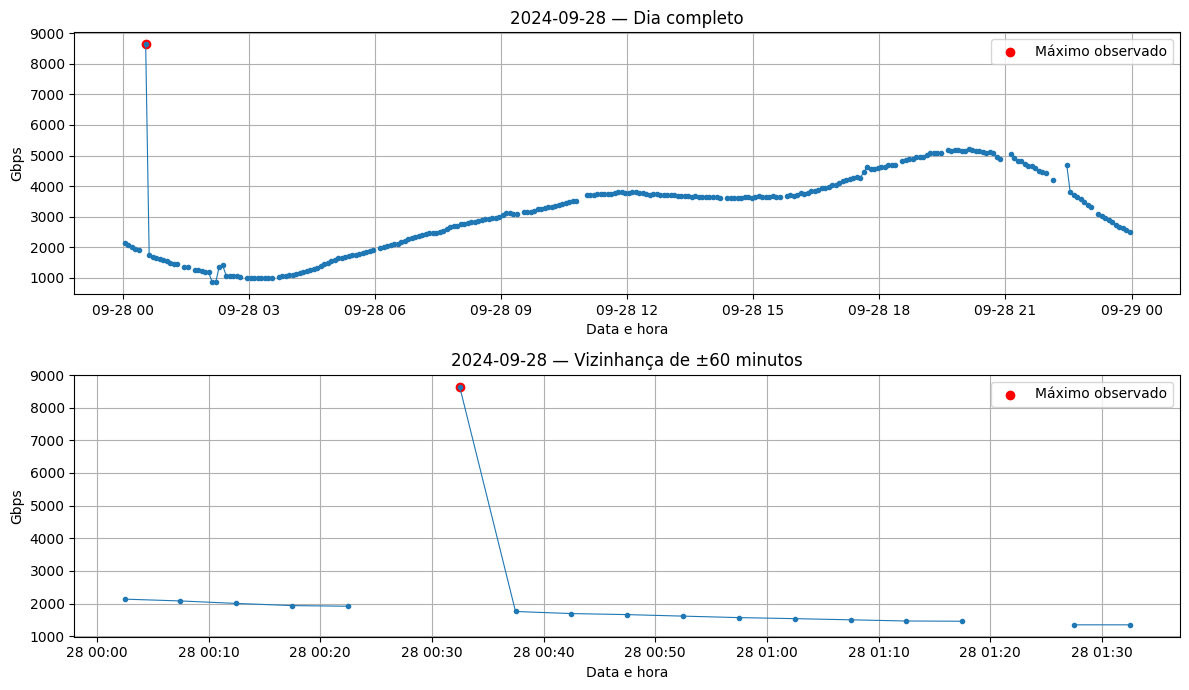

In [ ]:
# ------------------------------------------------------------
# Inspeciona o dia 2024-09-28 e as observações em torno do máximo diário.
# ------------------------------------------------------------

data_caso = pd.Timestamp("2024-09-28")
serie_caso = serie.loc[
    (serie.index >= data_caso) & (serie.index < data_caso + pd.Timedelta(days=1))
]
instante_max_caso = serie_caso.idxmax()
valor_max_caso = serie_caso.max()
display(dias.loc[[data_caso], ["count", "faltantes", "cobertura_pct", "max", "grupo"]].round(2))
display(robustez_grupos_df.loc[robustez_grupos_df["data"] == data_caso].round(2))
print(f"Máximo observado: {instante_max_caso} | {valor_max_caso:.2f} Gbps")
vizinhanca_caso = serie_caso.loc[
    (serie_caso.index >= instante_max_caso - pd.Timedelta(minutes=60)) &
    (serie_caso.index <= instante_max_caso + pd.Timedelta(minutes=60))
]
display(vizinhanca_caso.to_frame("total_gbps"))
fig, axes = plt.subplots(2, 1, figsize=(12, 7))
for ax, trecho, titulo in zip(
    axes, [serie_caso, vizinhanca_caso], ["Dia completo", "Vizinhança de ±60 minutos"]
):
    ax.plot(trecho.index, trecho, marker=".", linewidth=.8)
    ax.scatter([instante_max_caso], [valor_max_caso], color="red", label="Máximo observado")
    ax.set(title=f"2024-09-28 — {titulo}", xlabel="Data e hora", ylabel="Gbps")
    ax.legend()
plt.tight_layout()
plt.show()


O dia 2024-09-28 pertence a `recuperado_90`. O máximo observado é aproximadamente 8.641,61 Gbps, e o segundo maior valor corresponde a 60,34% dele. As medianas na vizinhança de ±30 e ±60 minutos correspondem, respectivamente, a 21,25% e 19,21% do máximo. Isso descreve um máximo destacado em relação às observações próximas; não permite concluir se houve erro de medição ou um evento real. Nenhum valor foi removido ou corrigido.

## Registro histórico do Welch dos máximos diários com 95%

Os resultados e textos abaixo são os registros anteriores à adoção de 90%. Não representam a análise atual e não são reexecutados neste auxiliar; o código e os resultados atuais do Welch dos máximos estão no Notebook 03. Nenhuma função espectral é necessária para executar este notebook.

### Saídas históricas da antiga célula 56 (95%)

```text
FFT de picos de 2023: 2023-01-01 até 2023-04-09 (99 dias)
2023: maior trecho diário = 99 dias; Welch = 30/49 janelas.
2024: maior trecho diário = 42 dias; Welch = 5/49 janelas.
Candidatos diários de 2023 e verificação nos mesmos bins em 2024:

```

```text
   frequencia_ciclos_dia  periodo_dias  periodo_horas  intensidade_espectral
0                 0.1414        7.0714       169.7143                 0.4352
1                 0.0404       24.7500       594.0000                 0.4292
2                 0.0707       14.1429       339.4286                 0.4183
3                 0.1919        5.2105       125.0526                 0.3376
4                 0.0909       11.0000       264.0000                 0.3330
5                 0.2828        3.5357        84.8571                 0.3233
6                 0.2626        3.8077        91.3846                 0.3141
7                 0.3636        2.7500        66.0000                 0.3121
```

```text
     ano      inicio         fim
0   2023  2023-01-01  2023-01-28
1   2023  2023-01-08  2023-02-04
2   2023  2023-01-15  2023-02-11
3   2023  2023-01-22  2023-02-18
4   2023  2023-01-29  2023-02-25
5   2023  2023-02-05  2023-03-04
6   2023  2023-02-12  2023-03-11
7   2023  2023-02-19  2023-03-18
8   2023  2023-02-26  2023-03-25
9   2023  2023-03-05  2023-04-01
10  2023  2023-03-12  2023-04-08
11  2023  2023-04-16  2023-05-13
12  2023  2023-04-23  2023-05-20
13  2023  2023-04-30  2023-05-27
14  2023  2023-05-07  2023-06-03
15  2023  2023-05-14  2023-06-10
16  2023  2023-05-21  2023-06-17
17  2023  2023-05-28  2023-06-24
18  2023  2023-06-04  2023-07-01
19  2023  2023-07-09  2023-08-05
20  2023  2023-07-16  2023-08-12
21  2023  2023-07-23  2023-08-19
22  2023  2023-07-30  2023-08-26
23  2023  2023-08-06  2023-09-02
24  2023  2023-08-13  2023-09-09
25  2023  2023-08-20  2023-09-16
26  2023  2023-08-27  2023-09-23
27  2023  2023-10-01  2023-10-28
28  2023  2023-10-08  2023-11-04
29  2023  2023-11-12  2023-12-09
30  2024  2024-01-01  2024-01-28
31  2024  2024-01-08  2024-02-04
32  2024  2024-01-15  2024-02-11
33  2024  2024-03-18  2024-04-14
34  2024  2024-10-07  2024-11-03
```

```text
   periodo_candidato_horas  ...  potencia_banda_2024_pct
0                 168.0000  ...                  52.1447
1                  84.0000  ...                   7.5598
2                  67.2000  ...                   6.6665
3                  51.6923  ...                  11.6472

[4 rows x 7 columns]
```

A análise dos máximos diários indica uma componente importante próxima de 7 dias. Na FFT de 2023, calculada sobre o maior trecho contínuo de 99 dias, o maior pico ocorre em aproximadamente 7,07 dias, embora existam outros picos de amplitude semelhante.
Na análise por janelas de 28 dias, 7 dias é o principal candidato identificado em 2023 e permanece como máximo local em 2024, com 41,3% da potência na banda em 2023 e 52,1% em 2024. A componente de 3,5 dias também persiste, mas pode representar uma harmônica do ciclo semanal.
Assim, os resultados fornecem evidência de uma estrutura semanal nos máximos diários, potencialmente relacionada a diferenças sistemáticas entre os dias da semana. Entretanto, a verificação em 2024 é limitada: apenas 5 das 49 janelas são válidas, e elas estão distribuídas de forma irregular ao longo do ano. Portanto, a recorrência semanal é sugestiva, mas deve ser interpretada com cautela.

Pq 2024 tem poquissimas janelas?

nessa análise dos máximos diários, vocês decidiram não interpolar os dias ausentes e manter o requisito de cobertura da função espectros_janelas().
O resultado mostra isso claramente:
2024: maior trecho diário = 42 dias; Welch = 5/49 janelas.

Cada janela precisa ter 28 dias com cobertura suficiente para ser considerada válida. Em 2024, os máximos diários têm lacunas distribuídas de tal forma que a maioria das janelas de 28 dias acaba sendo rejeitada.
Isso explica também a distribuição das únicas 5 janelas válidas:
- 01/01–28/01
- 08/01–04/02
- 15/01–11/02
- 18/03–14/04
- 07/10–03/11
Ou seja, não significa que 2024 tenha dados somente nesses períodos. Significa que apenas nesses intervalos há cobertura suficiente para satisfazer o critério de validade de uma janela completa.
Há ainda um efeito importante: como as janelas avançam apenas 7 dias, uma lacuna pode invalidar várias janelas sobrepostas. Por exemplo, um problema de cobertura dentro de determinado mês pode afetar sucessivamente as janelas que começam nas semanas anteriores e seguintes.
Isso também explica uma aparente diferença que vimos antes:
Série horária interpolada de 2024: 45/49 janelas válidas
Máximos diários de 2024: 5/49 janelas válidas
Na primeira análise, pequenas lacunas horárias foram interpoladas. Nesta seção, o próprio notebook estabelece:
“Não interpolamos máximos diários nem reduzimos o requisito de cobertura para obter mais janelas.”

Portanto, os máximos diários ficam muito mais sensíveis às lacunas.
Mas ainda não sabemos exatamente quais lacunas estão causando a perda de 44 janelas. Para isso, precisamos examinar a série series_anuais[2024]["picos"] e a regra exata usada por espectros_janelas() para considerar uma janela válida.